In [ ]:
# Title: 03_Astre_BayesAge_calibration.ipynb
# Author: Lajoyce Mboning
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the BayesAge clock on Astre et al

# Set Up

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from numpy import arange
from numpy import absolute
from numpy import mean
from numpy import std
import numpy as np
from scipy import stats
from sklearn.metrics import mean_absolute_error as mae
import statsmodels.api as sm
from scipy.stats import spearmanr
lowess = sm.nonparametric.lowess
from scipy.stats import poisson
from scipy.stats import pearsonr
from datetime import datetime
import time
import random
import itertools
from glob import glob
import re

In [2]:
# set working dir
# Get current notebook's directory
notebook_dir = '/labs/twc/Emma/atlas_gdrive_backup/revisions/CodeCheck_revisions/Astre_model_outputs/BayesAge/'

# Set working directory (here it's just confirming it's already set)
os.chdir(notebook_dir)

In [3]:
# List of directories you want to create
dirs_to_create = [
    "./reference/",
    "./predictions/",
    "./gene_sets/",
    "./plots/",
    "./predictions_exhaustive/",
    "./reference_exhaustive/"
]


for d in dirs_to_create:
    os.makedirs(d, exist_ok=True)  # exist_ok=True won't raise an error if it already exists

In [4]:
def transcriptome_reference(training_matrix,
                        reference_name,
                        output_path="./predictions/",
                        age_prediction="list",
                        age_list=[],
                        min_age=-20,
                        max_age=100,
                        age_step=1,
                        tau=0.7,
                        ):

    start_time = time.time()

    training_cv_df = training_matrix

    training_df_frequency = training_cv_df.iloc[:,:-1]

    #print(training_df_frequency)

    training_df_frequency = training_df_frequency.div(training_df_frequency.sum(axis=1), axis=0)

    genes = training_cv_df.iloc[:,:-1].columns.tolist()

    age_steps = np.arange(min_age, max_age + age_step, age_step)

    # Age values from the reference data
    age_training = training_cv_df["age"].values.flatten()

    final_training_matrix = []

    if age_prediction == "list":
        print("---- ENTERING GENE LOOP ----")
        print("Number of genes:", len(genes))
        for gene in genes:
            # Frequency level of current gene
            gene_frequency = training_df_frequency[gene].values.flatten()

            # Perform lowess smoothing
            predicted_frequency_levels = lowess(gene_frequency, age_training, xvals=age_list, frac=tau)

            # predicted = lowess(gene_frequency, age_training, xvals=age_list, frac=tau)

            # # Ensure only y values are kept
            # if isinstance(predicted, np.ndarray) and predicted.ndim == 2:
            #     predicted_frequency_levels = predicted[:, 1]
            # else:
            #     predicted_frequency_levels = predicted

            # Calculate Spearman rank correlation
            rho, p = spearmanr(age_training, gene_frequency)

            spearman_rank = rho

            p_value = p

            final_gene_frequency_tuple = (gene, ) + tuple(predicted_frequency_levels) + (spearman_rank, p_value)

            final_training_matrix.append(final_gene_frequency_tuple)

        print("age_list contents:", age_list)
        print("age_list types:", [type(a) for a in age_list])

        df_columns = ["Gene"] + [str(num) for num in age_list] + ["spearman_rank", "p_value"]

    elif age_prediction == "steps":

        for gene in genes:
            # Frequency level of current gene
            gene_frequency = training_df_frequency[gene].values.flatten()

            # Perform lowess smoothing
            predicted_frequency_levels = lowess(gene_frequency, age_training, xvals=age_steps, frac=tau)

            # Calculate Spearman rank correlation
            rho, p = spearmanr(age_training, gene_frequency)

            spearman_rank = rho

            p_value = p

            final_gene_frequency_tuple = (gene, ) + tuple(predicted_frequency_levels) + (spearman_rank, p_value)

            final_training_matrix.append(final_gene_frequency_tuple)

        df_columns = ["Gene"] + [str(num) for num in age_steps] + ["spearman_rank", "p_value"]


    df = pd.DataFrame(final_training_matrix, columns=df_columns)
    df.set_index("Gene", inplace=True)

    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    print("Attempting to write to:", os.path.join(output_path, reference_name))

    # Save the DataFrame to a TSV file
    df.to_csv(os.path.join(output_path, reference_name), sep="\t")
    print(f"\nReference model dataset written to '{os.path.join(output_path, reference_name)}'")

    number_of_samples = training_cv_df.shape[0]

    # Write report file detailing input matrix
    report_file_path = os.path.join(output_path, f'{reference_name}.report.txt')
    with open(report_file_path, 'w') as writer:
        writer.write("BayesAge reference report for %s\n" % reference_name)
        now = datetime.now()
        write_datetime = now.strftime("%m/%d/%Y %H:%M:%S")
        writer.write("Reference file created: %s\n\n" % write_datetime)
        writer.write("Number of input samples = %s\n" % number_of_samples)
        writer.write("Number of input Genes = %s\n" % len(genes))
        if age_prediction == "list":
            writer.write("Predictions made for ages: %s\n" % age_list)
        elif age_prediction == "steps":
            writer.write("Predictions made for age steps from %s to %s with step %s\n" % (min_age, max_age, age_step))

    print(f"Report file generated at '{report_file_path}'")
    print("-----------------------------------------------------\n\n")

    end_time = time.time()
    elapsed_time = end_time - start_time
    print("\nTime to run construct reference: %0.3f seconds" % elapsed_time)
    print("\nThe reference is constructed and saved!")

    return df  # Optionally return the DataFrame

# Load & format atlas data

In [5]:
# load raw counts
df_unnorm = pd.read_csv("../../AtlasFiles_forLajoyce_240507/Counts_Atlas_allbatches_merged_v3.csv")
df_unnorm.head(3)

,Unnamed: 0,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
0,a1cf,21686,52,5891,6,7544,18,10043,9,0,...,12,45920,3113,9682,4020,37522,1383,36,7855,14
1,aaas,623,585,1108,720,824,1072,1004,611,192,...,484,310,143,336,487,178,148,735,1383,717
2,aacs,1980,502,266,1913,238,2252,308,1614,56,...,1061,6587,291,3347,552,329,178,1124,382,1232


In [6]:
df_unnorm.rename(columns={"Unnamed: 0": "sample"}, inplace=True)
df_unnorm.set_index("sample", inplace=True)
df_unnorm.head(3)

,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,A13_2,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
sample,,,,,,,,,,,,,,,,,,,,,
a1cf,21686,52,5891,6,7544,18,10043,9,0,30,...,12,45920,3113,9682,4020,37522,1383,36,7855,14
aaas,623,585,1108,720,824,1072,1004,611,192,591,...,484,310,143,336,487,178,148,735,1383,717
aacs,1980,502,266,1913,238,2252,308,1614,56,227,...,1061,6587,291,3347,552,329,178,1124,382,1232


In [7]:
df_unnorm = df_unnorm.T
df_unnorm.head(3)

sample,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_1,21686,623,1980,523,200,802,1242,1224,562,577,...,829,161,1014,220,1560,42,515,3018,1422,325
A1_2,52,585,502,537,709,674,1385,2329,652,646,...,1113,92,963,153,1118,27,966,3871,275,364
A10_1,5891,1108,266,676,233,835,1374,809,716,778,...,635,156,1650,137,1370,380,662,3191,498,477


In [8]:
# load metadata
df_metadata = pd.read_csv("../../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [9]:
df_metadata.reset_index()

,index,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,...,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,...,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,...,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,...,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN
3,3,A10_2,J_1A_14,M,1A,75,11/22/21,9/8/21,SpinalCord,NaN,...,SpinalCord_1,EC,RNA423,2,A10,A10,A10_2,NaN,NaN,NaN
4,4,A11_1,J_1A_22,M,1A,47,10/25/21,9/8/21,Kidney,NaN,...,Kidney_2,JC,R274,1,A11,A11,A11_1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,672,P7_1,J_1A_25,M,1A,103,12/20/21,9/8/21,Liver,NaN,...,Liver_1,IG,RNA689,1,P7,P7,P7_1,NaN,NaN,NaN
673,673,P7_2,P_1B_1,F,1B,77,12/6/21,9/20/21,Fat,4/13/23,...,Fat_3,EC,RNA566,2,P7,P7,P7_2,NaN,NaN,NaN
674,674,P8_2,J_1A_25,M,1A,103,12/20/21,9/8/21,Eye,NaN,...,Eye_1,MRW,642,2,P8,P8,P8_2,NaN,NaN,NaN
675,675,P9_1,J_1B_2,M,1B,49,11/8/21,9/20/21,Kidney,NaN,...,Kidney_1,JC,R257,1,P9,P9,P9_1,NaN,NaN,NaN


In [10]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [11]:
df_metadata.set_index("sample", inplace=True)
df_metadata.head(2)

,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
sample,,,,,,,,,,,,,,,,,,,
A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN


In [12]:
# Merge based on index
combined_df = pd.concat([df_unnorm, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)
combined_df.rename(columns={"age_days": "age"}, inplace=True)
combined_df.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A1_1,21686,623,1980,523,200,802,1242,1224,562,577,...,220,1560,42,515,3018,1422,325,F,Gut,155
A1_2,52,585,502,537,709,674,1385,2329,652,646,...,153,1118,27,966,3871,275,364,M,Bone,78
A10_1,5891,1108,266,676,233,835,1374,809,716,778,...,137,1370,380,662,3191,498,477,M,Kidney,133


# Load & format intervention data

In [13]:
#raw counts from intervention dataset
df_intervention = pd.read_csv("../../Data_from_Others/Astre_et_al_2023/remap_EKC/Counts_AstreLiver_250606.csv")
df_intervention.head(3)

,SRR17215646,SRR17215657,SRR17215658,SRR17215659,SRR17215660,SRR17215661,SRR17215662,SRR17215663,SRR17215664,SRR17215665,...,SRR17215652,SRR17215653,SRR17215654,SRR17215655,SRR17215656,SRR17215674,SRR17215675,SRR17215676,SRR17215682,SRR17215685
LOC107380275,6,0,1,4,9,6,2,3,5,8,...,0,1,3,2,1,2,3,0,2,3
LOC107389369,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
klf12,646,541,448,380,1028,343,669,602,595,476,...,777,412,446,210,383,197,457,387,183,187


In [14]:
df_intervention = df_intervention.T
df_intervention.head(2)

,LOC107380275,LOC107389369,klf12,enpp2,LOC107382607,LOC107386405,wwox,LOC107388920,csgr14h3orf70,LOC107376005,...,LOC107391152,LOC107394127,golph3,LOC107381980,LOC107390548,lhfpl5,LOC107373016,LOC107392495,LOC107396697,LOC107391667
SRR17215646,6,0,646,16,59,210,142,99,127,297,...,3,0,562,2,238,0,1,237,0,0
SRR17215657,0,0,541,21,45,51,48,42,53,288,...,1,0,284,0,50,0,0,182,0,0


In [15]:
df_intervention_metadata = pd.read_csv("../../Data_from_Others/Astre_et_al_2023/remap_EKC/ExperimentDesign_AstreLiver_update_20250629.csv")
df_intervention_metadata.set_index("Run", inplace=True)
df_intervention_metadata.head(2)

,lib,age,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center.Name,Consent,...,create_date,version,Sample.Name,sex,source_name,SRA.Study,tissue,file,UsedForTraining,ExcludedFromAnalysis
Run,,,,,,,,,,,,,,,,,,,,,
SRR17215646,SRR17215646,15 weeks,RNA-Seq,74,3525629281,PRJNA788399,SAMN23970501,1614398132,GEO,public,...,2021-12-13T12:06:00Z,1,GSM5730981,male,Nfr Liver,SRP350511,Liver,SRR17215646.featureCounts,Yes,Include
SRR17215657,SRR17215657,6.5 weeks,RNA-Seq,74,2840020025,PRJNA788399,SAMN23970512,1302718445,GEO,public,...,2021-12-13T12:07:00Z,1,GSM5730992,male,Nfr Liver,SRP350511,Liver,SRR17215657.featureCounts,No,Include


In [16]:
# Parse the index and extract components
df_intervention["tissue"] = df_intervention_metadata["tissue"].tolist()
df_intervention["AGE"] = df_intervention_metadata["age"].tolist()
df_intervention["sex"] = df_intervention_metadata["sex"].tolist()
df_intervention["training"] = df_intervention_metadata["UsedForTraining"].tolist()
df_intervention["genotype"] = df_intervention_metadata["genotype"].tolist()
df_intervention["feeding_condition"] = df_intervention_metadata["feeding_condition"].tolist()
df_intervention.head(2)

,LOC107380275,LOC107389369,klf12,enpp2,LOC107382607,LOC107386405,wwox,LOC107388920,csgr14h3orf70,LOC107376005,...,LOC107373016,LOC107392495,LOC107396697,LOC107391667,tissue,AGE,sex,training,genotype,feeding_condition
SRR17215646,6,0,646,16,59,210,142,99,127,297,...,1,237,0,0,Liver,15 weeks,male,Yes,WT,full
SRR17215657,0,0,541,21,45,51,48,42,53,288,...,0,182,0,0,Liver,6.5 weeks,male,No,Het,full


In [17]:
age_mapping = {
    "6.5 weeks": 46, #round up from 45.5
    "15 weeks": 105
}

df_intervention["age"] = df_intervention["AGE"].map(age_mapping)
df_intervention.head(2)

,LOC107380275,LOC107389369,klf12,enpp2,LOC107382607,LOC107386405,wwox,LOC107388920,csgr14h3orf70,LOC107376005,...,LOC107392495,LOC107396697,LOC107391667,tissue,AGE,sex,training,genotype,feeding_condition,age
SRR17215646,6,0,646,16,59,210,142,99,127,297,...,237,0,0,Liver,15 weeks,male,Yes,WT,full,105
SRR17215657,0,0,541,21,45,51,48,42,53,288,...,182,0,0,Liver,6.5 weeks,male,No,Het,full,46


In [18]:
df_intervention['sex'] = df_intervention['sex'].replace('male', 'M')
df_intervention['sex'] = df_intervention['sex'].replace('female', 'F')

select_tissue = 'Liver'

# Age prediction with "calibration"

In [19]:
df_intervention_male = df_intervention.loc[
    (df_intervention.iloc[:, -7] == select_tissue) &
    (df_intervention.iloc[:, -5] == 'M')
]

In [21]:
random.seed(123)

all_samples = df_intervention_male.index

#for calibration, only use WT full samples
WT_samples = df_intervention_male[
    (df_intervention_male['genotype'] == 'WT') &
    (df_intervention_male['feeding_condition'] == 'full')].index
#get rid of fasted samples, remove the test samples that have "fasted" in the name
WT_samples = sorted(WT_samples)
WT_samples

# Separate the samples
young_samples = [s for s in WT_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'age'] == 46]
old_samples = [s for s in WT_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'age'] == 105]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

df_intervention_train = df_intervention_male.loc[
    df_intervention_male.index.isin(select_train_samples)
]

df_intervention_train

,LOC107380275,LOC107389369,klf12,enpp2,LOC107382607,LOC107386405,wwox,LOC107388920,csgr14h3orf70,LOC107376005,...,LOC107392495,LOC107396697,LOC107391667,tissue,AGE,sex,training,genotype,feeding_condition,age
SRR17215646,6,0,646,16,59,210,142,99,127,297,...,237,0,0,Liver,15 weeks,M,Yes,WT,full,105
SRR17215647,5,0,456,49,101,100,116,121,30,193,...,231,0,0,Liver,15 weeks,M,Yes,WT,full,105
SRR17215653,1,0,412,30,65,65,62,83,36,234,...,145,0,0,Liver,6.5 weeks,M,Yes,WT,full,46
SRR17215654,3,0,446,20,52,66,58,57,59,324,...,175,0,0,Liver,6.5 weeks,M,Yes,WT,full,46


In [22]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['SRR17215657',
 'SRR17215658',
 'SRR17215659',
 'SRR17215660',
 'SRR17215661',
 'SRR17215662',
 'SRR17215663',
 'SRR17215664',
 'SRR17215665',
 'SRR17215666',
 'SRR17215667',
 'SRR17215668',
 'SRR17215669',
 'SRR17215670',
 'SRR17215671',
 'SRR17215672',
 'SRR17215648',
 'SRR17215649',
 'SRR17215650',
 'SRR17215651',
 'SRR17215652',
 'SRR17215655',
 'SRR17215656']

In [23]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_male.loc[
    df_intervention_male.index.isin(test_samples)
]

df_intervention_test.head(3)

,LOC107380275,LOC107389369,klf12,enpp2,LOC107382607,LOC107386405,wwox,LOC107388920,csgr14h3orf70,LOC107376005,...,LOC107392495,LOC107396697,LOC107391667,tissue,AGE,sex,training,genotype,feeding_condition,age
SRR17215657,0,0,541,21,45,51,48,42,53,288,...,182,0,0,Liver,6.5 weeks,M,No,Het,full,46
SRR17215658,1,0,448,9,54,43,50,55,51,275,...,144,0,0,Liver,6.5 weeks,M,No,Het,full,46
SRR17215659,4,0,380,19,49,53,49,57,79,246,...,136,0,0,Liver,6.5 weeks,M,No,Het,full,46


### Male - transcriptome reference

In [24]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
    (combined_df.iloc[:, -3] == 'M')
]
tissue_df_counts['feeding_condition'] = 'fed'
tissue_df_counts['genotype'] = 'wt'
tissue_df_counts.head(5)

/local/scratch/emkcosta/slrmtmp.48768281/ipykernel_18363/3377620404.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tissue_df_counts['feeding_condition'] = 'fed'
/local/scratch/emkcosta/slrmtmp.48768281/ipykernel_18363/3377620404.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tissue_df_counts['genotype'] = 'wt'


,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,feeding_condition,genotype
A5_1,36508,206,3342,296,14,375,356,1593,339,202,...,0,185,928,108,162,M,Liver,134,fed,wt
A8_1,56721,239,1240,467,30,416,444,1032,402,261,...,8,229,1014,153,168,M,Liver,133,fed,wt
B7_1,46082,190,5874,288,30,465,555,1129,332,306,...,2,235,1049,250,243,M,Liver,133,fed,wt
C5_1,41639,254,8813,231,22,423,336,1167,313,270,...,8,174,852,86,159,M,Liver,162,fed,wt
C7_1,46991,267,3752,349,38,556,637,1162,378,377,...,6,223,1268,156,190,M,Liver,152,fed,wt


In [25]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,feeding_condition,genotype
SRR17215646,62099,382,9166,393,60,385,517,495,572,269,...,181,423,1716,1050,530,M,Liver,105,full,WT
SRR17215647,59262,374,4099,470,39,457,471,541,551,238,...,258,403,1641,1273,469,M,Liver,105,full,WT


In [26]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,feeding_condition,genotype
A5_1,36508,206,3342,296,14,375,356,1593,339,202,...,0,185,928,108,162,M,Liver,134,fed,wt
A8_1,56721,239,1240,467,30,416,444,1032,402,261,...,8,229,1014,153,168,M,Liver,133,fed,wt
B7_1,46082,190,5874,288,30,465,555,1129,332,306,...,2,235,1049,250,243,M,Liver,133,fed,wt


In [27]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [28]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[46, 47, 49, 52, 75, 77, 78, 102, 103, 105, 133, 134, 147, 152, 161, 162]


In [29]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-1,-2,-4, -5]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_1,36508,206,3342,296,14,375,356,1593,339,202,...,25,262,36,414,0,185,928,108,162,134
A8_1,56721,239,1240,467,30,416,444,1032,402,261,...,22,319,52,470,8,229,1014,153,168,133


In [30]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./reference/liver_sample_{sample}.csv", sep="\t")

In [31]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [32]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name="killifish_liver_reference_male",
                            output_path="./reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

---- ENTERING GENE LOOP ----
Number of genes: 25122


/scg/apps/software/jupyter/python_3.9/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4878: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


age_list contents: [ 46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63
  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81
  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99
 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153
 154 155 156 157 158 159 160 161 162]
age_list types: [<class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <clas

,46,47,48,49,50,51,52,53,54,55,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,1.328625e-03,1.330668e-03,1.332769e-03,1.334924e-03,1.337130e-03,1.339383e-03,1.341680e-03,1.344020e-03,1.346402e-03,1.348825e-03,...,1.509344e-03,1.507446e-03,1.505539e-03,1.503623e-03,1.501696e-03,1.499757e-03,1.497804e-03,1.495835e-03,0.162140,0.352074
aaas,8.783465e-06,8.781041e-06,8.778748e-06,8.776600e-06,8.774603e-06,8.772749e-06,8.771024e-06,8.769418e-06,8.767931e-06,8.766563e-06,...,8.500381e-06,8.515135e-06,8.530489e-06,8.546420e-06,8.562908e-06,8.579932e-06,8.597471e-06,8.615505e-06,0.023724,0.892393
aacs,1.351958e-04,1.333026e-04,1.314225e-04,1.295577e-04,1.277102e-04,1.258814e-04,1.240727e-04,1.222853e-04,1.205193e-04,1.187747e-04,...,1.577447e-04,1.597813e-04,1.618287e-04,1.638871e-04,1.659566e-04,1.680374e-04,1.701295e-04,1.722330e-04,0.327930,0.054460
aadat,1.233903e-05,1.229435e-05,1.224987e-05,1.220562e-05,1.216159e-05,1.211777e-05,1.207416e-05,1.203076e-05,1.198756e-05,1.194456e-05,...,9.372445e-06,9.359723e-06,9.347174e-06,9.334771e-06,9.322492e-06,9.310314e-06,9.298215e-06,9.286171e-06,-0.578930,0.000269
aaed1,1.274259e-06,1.273845e-06,1.273464e-06,1.273117e-06,1.272806e-06,1.272530e-06,1.272286e-06,1.272072e-06,1.271889e-06,1.271737e-06,...,8.378867e-07,8.347390e-07,8.317455e-07,8.289045e-07,8.262143e-07,8.236732e-07,8.212791e-07,8.190299e-07,-0.296905,0.083270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,5.156981e-07,5.095757e-07,5.035083e-07,4.974970e-07,4.915411e-07,4.856399e-07,4.797924e-07,4.739979e-07,4.682561e-07,4.625669e-07,...,9.440753e-08,9.205084e-08,8.973722e-08,8.746686e-08,8.523996e-08,8.305664e-08,8.091701e-08,7.882111e-08,-0.269209,0.117853
zyg11b,8.515149e-06,8.497110e-06,8.478934e-06,8.460603e-06,8.442095e-06,8.423388e-06,8.404457e-06,8.385282e-06,8.365861e-06,8.346194e-06,...,6.807114e-06,6.804802e-06,6.802520e-06,6.800263e-06,6.798031e-06,6.795818e-06,6.793624e-06,6.791443e-06,-0.393207,0.019451
zyx,4.487828e-05,4.483269e-05,4.478754e-05,4.474285e-05,4.469864e-05,4.465489e-05,4.461159e-05,4.456869e-05,4.452621e-05,4.448415e-05,...,3.617802e-05,3.616089e-05,3.614664e-05,3.613517e-05,3.612640e-05,3.612021e-05,3.611652e-05,3.611521e-05,-0.460589,0.005364


In [ ]:
df_intervention_test.head(1)

,LOC107380275,LOC107389369,klf12,enpp2,LOC107382607,LOC107386405,wwox,LOC107388920,csgr14h3orf70,LOC107376005,...,LOC107392495,LOC107396697,LOC107391667,tissue,AGE,sex,training,genotype,feeding_condition,age
SRR17215657,0,0,541,21,45,51,48,42,53,288,...,182,0,0,Liver,6.5 weeks,M,No,Het,full,46


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5,-6, -7]], axis=1)
df_intervention_test_counts.head(3)

,LOC107380275,LOC107389369,klf12,enpp2,LOC107382607,LOC107386405,wwox,LOC107388920,csgr14h3orf70,LOC107376005,...,LOC107394127,golph3,LOC107381980,LOC107390548,lhfpl5,LOC107373016,LOC107392495,LOC107396697,LOC107391667,age
SRR17215657,0,0,541,21,45,51,48,42,53,288,...,0,284,0,50,0,0,182,0,0,46
SRR17215658,1,0,448,9,54,43,50,55,51,275,...,0,266,0,29,0,0,144,0,0,46
SRR17215659,4,0,380,19,49,53,49,57,79,246,...,0,207,0,21,0,0,136,0,0,46


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./reference/killifish_liver_reference_male", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    top_genes = top_abs_spearman_corr.index.tolist()


    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

            prediction
SRR17215657       47.0
SRR17215658       88.0
SRR17215659       47.0
SRR17215660       49.0
SRR17215661       88.0
SRR17215662       48.0
SRR17215663       69.0
SRR17215664       89.0
SRR17215665       63.0
SRR17215666       50.0
SRR17215667       46.0
SRR17215668       46.0
SRR17215669      115.0
SRR17215670       55.0
SRR17215671       46.0
SRR17215672       61.0
SRR17215648       47.0
SRR17215649       61.0
SRR17215650       46.0
SRR17215651       66.0
SRR17215652       57.0
SRR17215655       47.0
SRR17215656       46.0


In [ ]:
df_intervention_test_pred["feeding_condition"] = df_intervention_test["feeding_condition"].tolist()
df_intervention_test_pred["genotype"] = df_intervention_test["genotype"].tolist()
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()

df_intervention_test_pred["age_genotype_treatment"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["genotype"].astype(str) + "_" +
    df_intervention_test_pred["feeding_condition"].astype(str)
)

df_intervention_test_pred

,prediction,feeding_condition,genotype,age,age_genotype_treatment
SRR17215657,47.0,full,Het,46,46_Het_full
SRR17215658,88.0,full,Het,46,46_Het_full
SRR17215659,47.0,full,Het,46,46_Het_full
SRR17215660,49.0,fasted,WT,105,105_WT_fasted
SRR17215661,88.0,fasted,WT,105,105_WT_fasted
SRR17215662,48.0,fasted,WT,105,105_WT_fasted
SRR17215663,69.0,fasted,Het,105,105_Het_fasted
SRR17215664,89.0,fasted,Het,105,105_Het_fasted
SRR17215665,63.0,fasted,Het,105,105_Het_fasted
SRR17215666,50.0,fasted,WT,46,46_WT_fasted


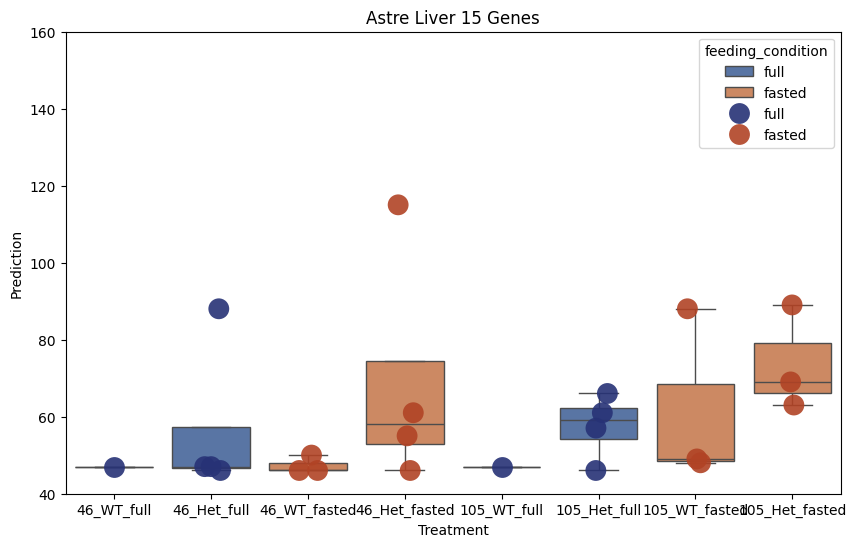

In [ ]:
ordered_x = [
    '46_WT_full', '46_Het_full',
    '46_WT_fasted', '46_Het_fasted',
    '105_WT_full', '105_Het_full',
    '105_WT_fasted', '105_Het_fasted'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_genotype_treatment', y='prediction', hue='feeding_condition', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_genotype_treatment',
    y='prediction',
    hue='feeding_condition',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join(['Astre Liver ', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

# Show the plot
plt.show()

### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
    '46_WT_full', '46_Het_full',
    '46_WT_fasted', '46_Het_fasted',
    '105_WT_full', '105_Het_full',
    '105_WT_fasted', '105_Het_fasted'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 201, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./reference/killifish_liver_reference_male", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["feeding_condition"] = df_intervention_test["feeding_condition"].tolist()
    df_intervention_test_pred["genotype"] = df_intervention_test["genotype"].tolist()
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["age_genotype_treatment"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["genotype"].astype(str) + "_" +
        df_intervention_test_pred["feeding_condition"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/age_preds_top_{gene_number}_genes.tsv", sep="\t")



    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 165 genes...
Saved plot and prediction for 165 genes.

Running prediction for top 170 genes...
Saved plot and prediction for 170 genes.

Running prediction for top 175 genes...
Saved plot and prediction for 175 genes.

Running prediction for top 180 genes...
Saved plot and prediction for 180 genes.

Running prediction for top 185 genes...
Saved plot and prediction for 185 genes.

Running prediction for top 190 genes...
Saved plot and prediction for 190 genes.

Running prediction for top 195 genes...
Saved plot and prediction for 195 genes.

Running prediction for top 200 genes...
Saved plot and prediction for 200 genes.



### Plot stability of predictions over range of gene set sizes

/tmp/ipython-input-80-3756722152.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-80-3756722152.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-80-3756722152.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-80-3756722152.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


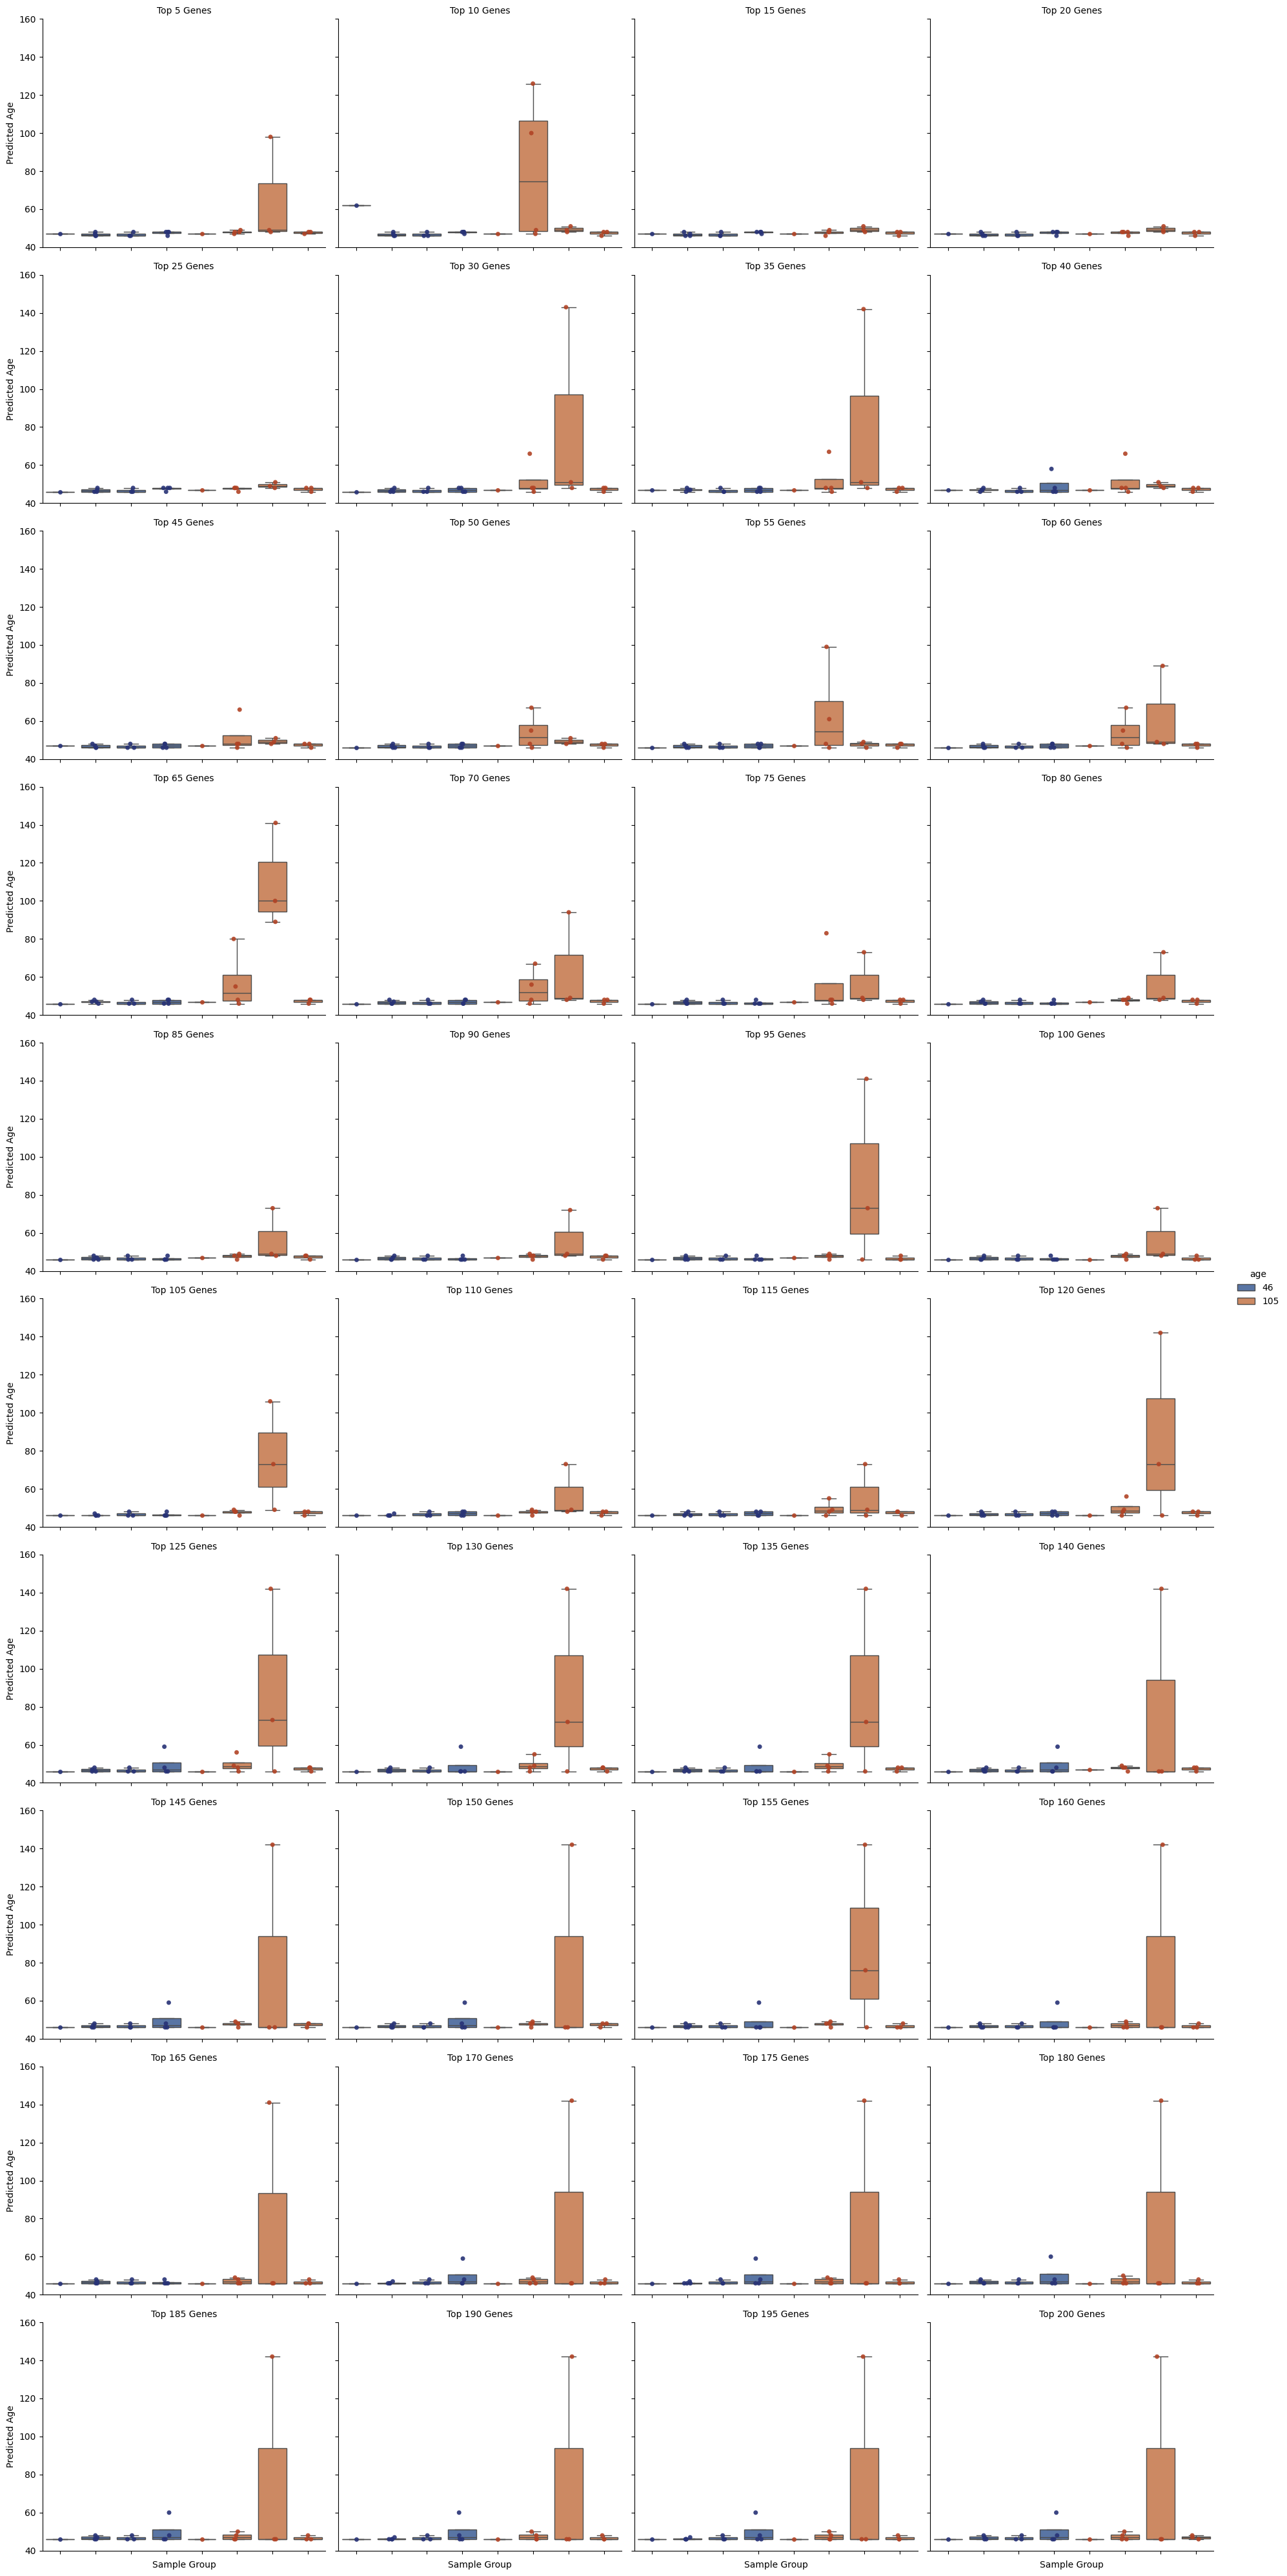

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '46_WT_full', '46_Het_full',
    '46_WT_fasted', '46_Het_fasted',
    '105_WT_full', '105_Het_full',
    '105_WT_fasted', '105_Het_fasted'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 201, 5):
    file_path = f"./predictions/age_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)
all_predictions_df.head(2)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_genotype_treatment",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_genotype_treatment',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig("./plots/faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


# Rotate training samples

### Calculate predictions for all gene set sizes

In [33]:
#------------------------------------------------------------
# Sample selection setup
#------------------------------------------------------------
WT_samples = df_intervention_male[
    (df_intervention_male['genotype'] == 'WT') &
    (df_intervention_male['feeding_condition'] == 'full')
].index

young_samples = sorted([s for s in WT_samples if df_intervention_male.loc[s, 'age'] == 46])
old_samples = sorted([s for s in WT_samples if df_intervention_male.loc[s, 'age'] == 105])

# Create all 2x2 combinations
young_combos = list(itertools.combinations(young_samples, 2))
old_combos = list(itertools.combinations(old_samples, 2))


#------------------------------------------------------------
# Loop through all young-old combinations
#------------------------------------------------------------
for y_combo in young_combos:
    for o_combo in old_combos:

        combo_id = f"{'_'.join(map(str, y_combo))}__{'_'.join(map(str, o_combo))}"
        print(f"\nRunning combo: {combo_id}")

        # Select samples for training
        select_train_samples = list(y_combo) + list(o_combo)
        df_intervention_train = df_intervention_male.loc[select_train_samples]
        df_intervention_train = df_intervention_train[tissue_df_counts.columns]  # match columns

        # Combine with atlas
        atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
        age_steps = sorted(atlas_plus_intervention["age"].value_counts().index.tolist())

        atlas_plus_intervention = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-1, -2, -4, -5]], axis=1)

        # Get test set
        test_samples = [s for s in df_intervention_male.index if s not in select_train_samples]
        df_intervention_test = df_intervention_male.loc[test_samples]
        df_intervention_test_counts = df_intervention_test.drop(
            df_intervention_test.columns[[-2, -3, -4, -5, -6, -7]], axis=1
        )

        # Save per-sample reference files
        for sample in atlas_plus_intervention.index:
            atlas_plus_intervention.drop(sample).to_csv(
                f"./reference/liver_sample_{sample}_{combo_id}.csv", sep="\t"
            )

        new_age_steps = np.arange(min(age_steps), max(age_steps) + 1, 1)


        # Run transcriptome_reference (assuming it handles saving internally)
        transcriptome_reference(
            training_matrix=atlas_plus_intervention,
            reference_name=f"killifish_liver_ref_{combo_id}",
            output_path="./reference_exhaustive/",
            age_prediction="list",
            age_list=new_age_steps,
            min_age=1,
            max_age=24,
            age_step=1,
            tau=0.7
        )


        # Run predictions for a single gene number or loop over multiple
        for gene_number in range(5, 201, 5):
            df_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])
            reference_df = pd.read_csv(
                f"./reference_exhaustive/killifish_liver_ref_{combo_id}", sep="\t", index_col=0
            )
            top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

            for sample in df_intervention_test.index:
                total_reads = df_intervention_test_counts.loc[sample].sum()
                log_sums = []
                for age in new_age_steps:
                    logP = []
                    for gene in top_genes:
                        freq = max(reference_df.loc[gene, str(age)], 1e-10)
                        mu = freq * total_reads
                        obs = df_intervention_test_counts.loc[sample, gene]
                        p = max(poisson.pmf(obs, mu), 0.001)
                        logP.append(np.log(p))
                    log_sums.append(np.sum(logP))

                pred_age = round(float(new_age_steps[np.argmax(log_sums)]), 2)
                df_pred.loc[sample, "prediction"] = pred_age

            # Add metadata and save
            df_pred["feeding_condition"] = df_intervention_test["feeding_condition"]
            df_pred["genotype"] = df_intervention_test["genotype"]
            df_pred["age"] = df_intervention_test["age"]
            df_pred["age_genotype_treatment"] = (
                df_pred["age"].astype(str) + "_" +
                df_pred["genotype"] + "_" +
                df_pred["feeding_condition"]
            )

            # Save prediction results
            df_pred.to_csv(
                f"./predictions_exhaustive/pred_top_{gene_number}_{combo_id}.tsv", sep="\t"
            )



Running combo: SRR17215653_SRR17215654__SRR17215646_SRR17215647
---- ENTERING GENE LOOP ----
Number of genes: 25122


/scg/apps/software/jupyter/python_3.9/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4878: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


age_list contents: [ 46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63
  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81
  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99
 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153
 154 155 156 157 158 159 160 161 162]
age_list types: [<class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <clas

/scg/apps/software/jupyter/python_3.9/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4878: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


age_list contents: [ 46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63
  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81
  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99
 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153
 154 155 156 157 158 159 160 161 162]
age_list types: [<class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <clas

...

age_list contents: [ 46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63
  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81
  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99
 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153
 154 155 156 157 158 159 160 161 162]
age_list types: [<class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <clas

/scg/apps/software/jupyter/python_3.9/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4878: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


age_list contents: [ 46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63
  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81
  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99
 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153
 154 155 156 157 158 159 160 161 162]
age_list types: [<class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <clas

/scg/apps/software/jupyter/python_3.9/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4878: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


age_list contents: [ 46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63
  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81
  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99
 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153
 154 155 156 157 158 159 160 161 162]
age_list types: [<class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <class 'numpy.int64'>, <clas

### Plot predictions with legend

/local/scratch/emkcosta/slrmtmp.48768281/ipykernel_18363/3544579642.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/local/scratch/emkcosta/slrmtmp.48768281/ipykernel_18363/3544579642.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/local/scratch/emkcosta/slrmtmp.48768281/ipykernel_18363/3544579642.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/local/scratch/emkcosta/slrmtmp.48768281/ipykernel_18363/3544579642.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using 

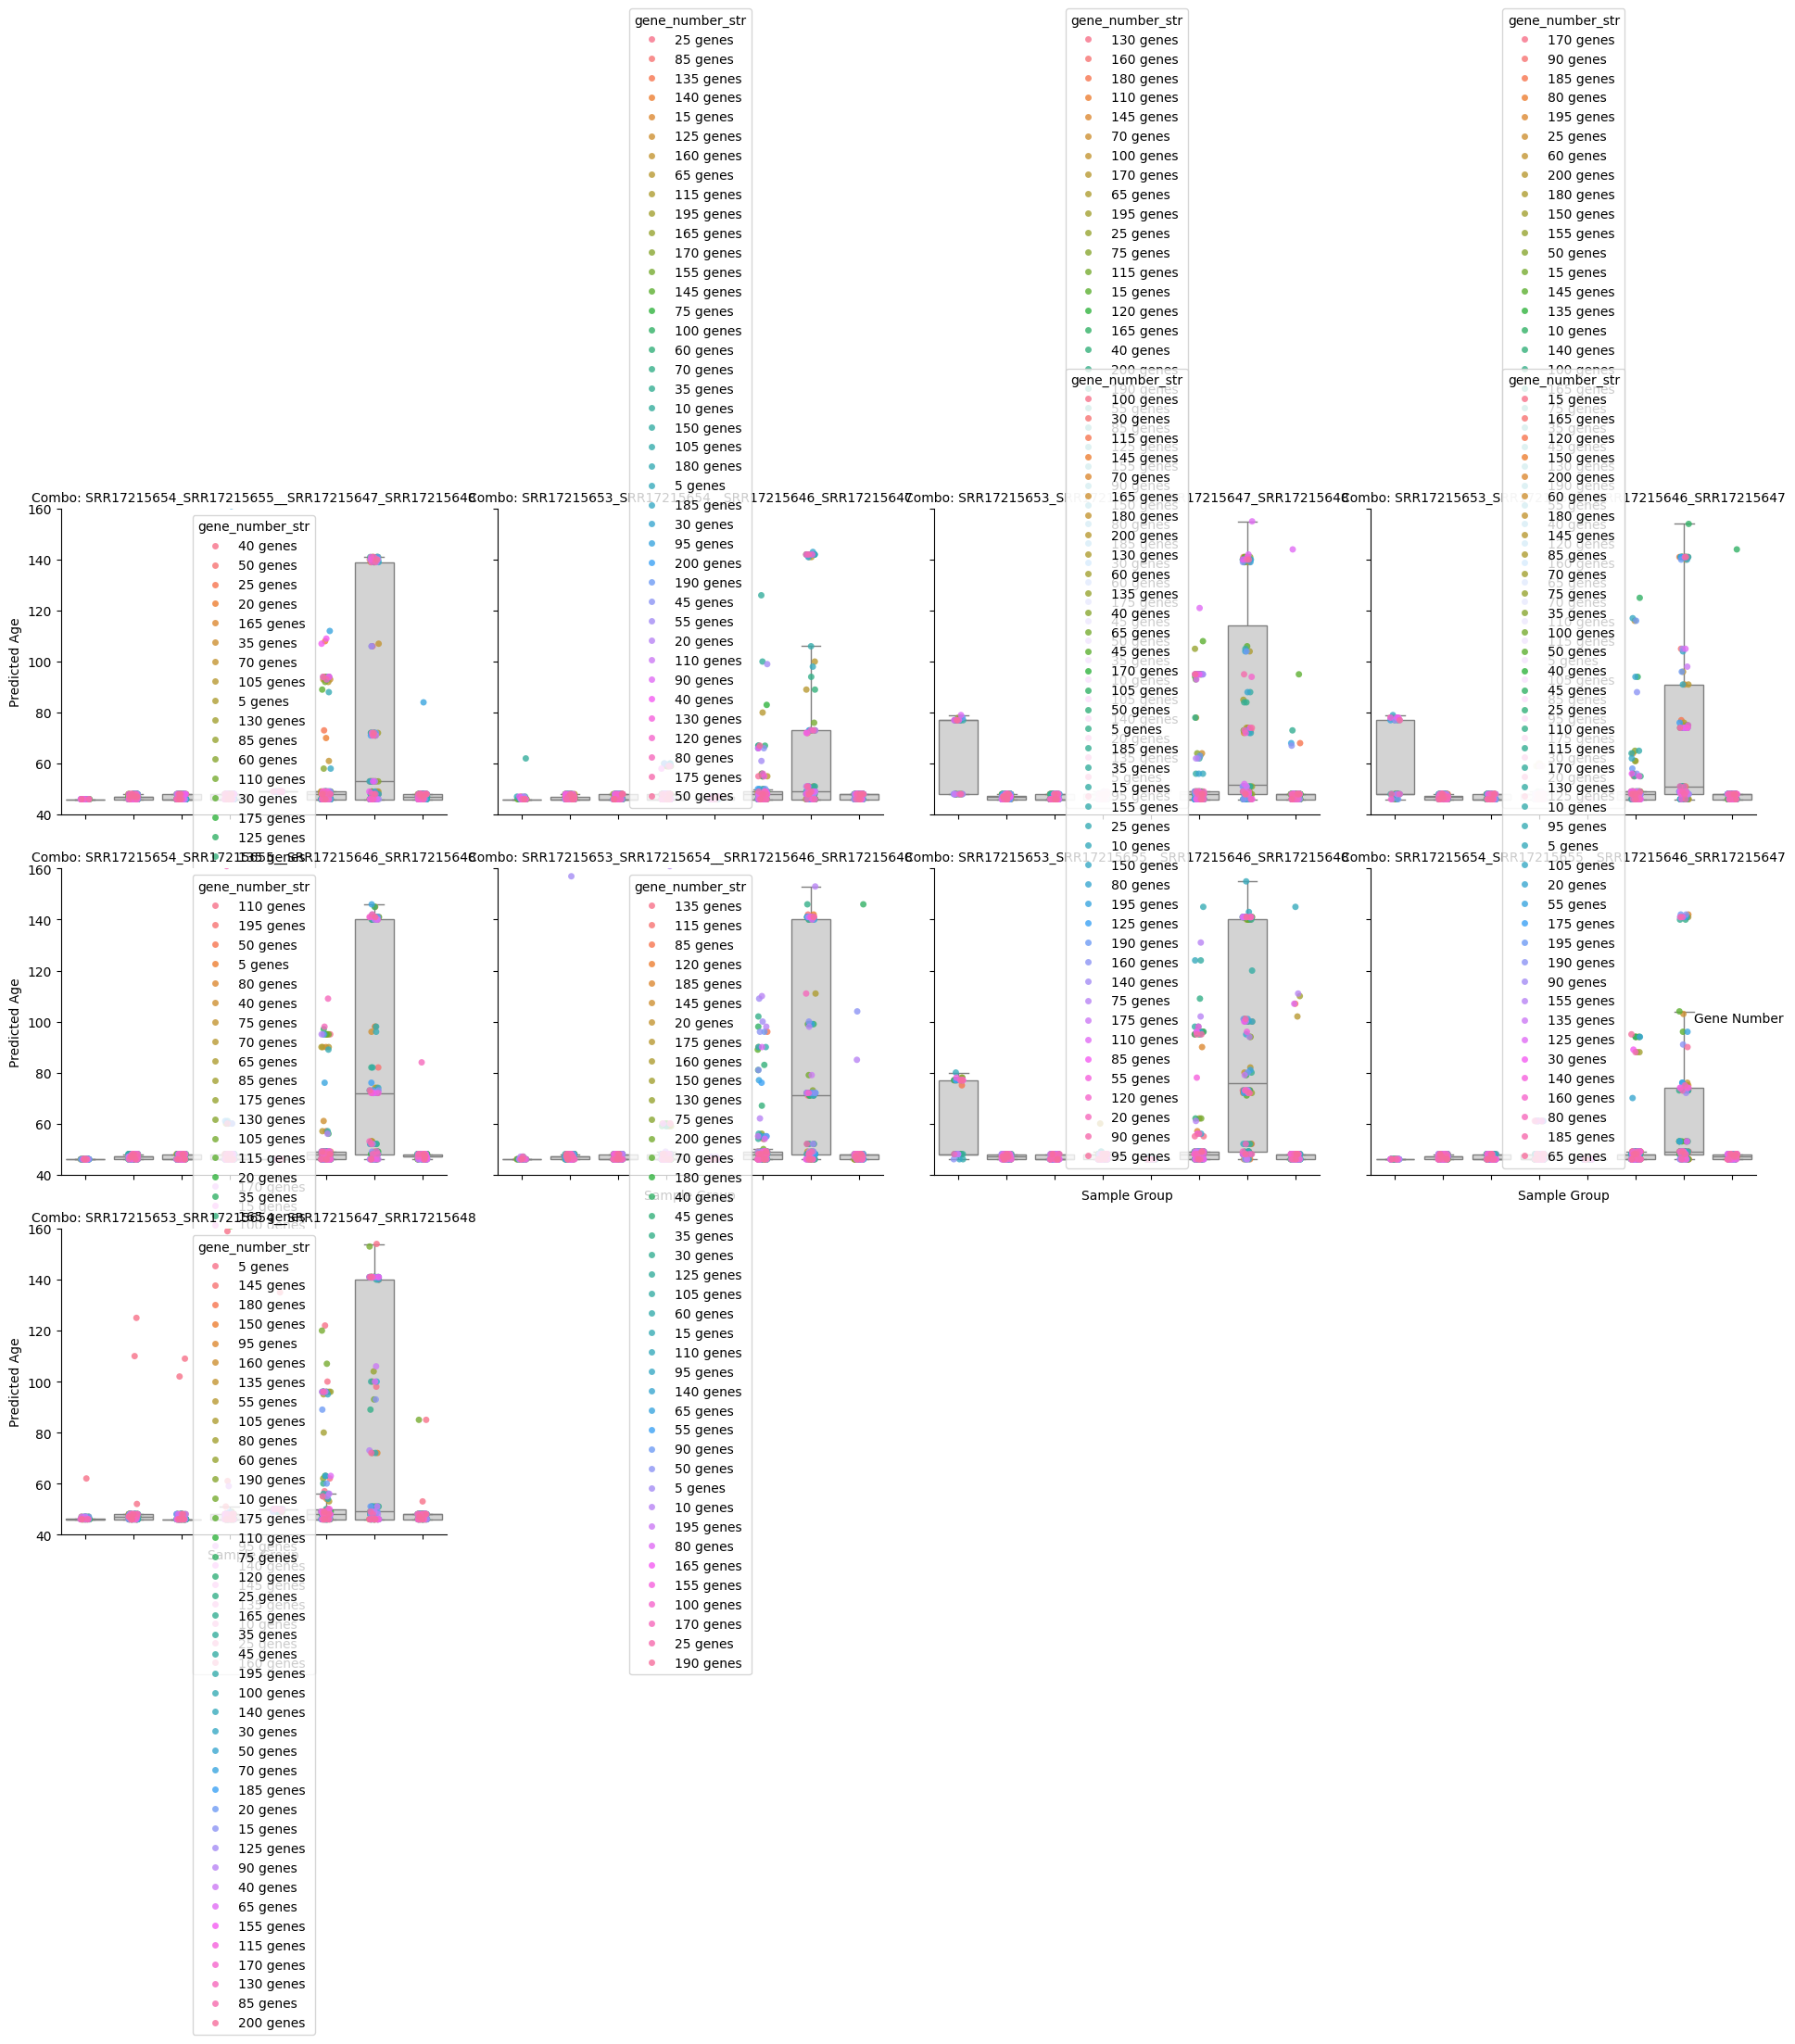

In [34]:
# Define plotting preferences
ordered_x = [
    '46_WT_full', '46_Het_full',
    '46_WT_fasted', '46_Het_fasted',
    '105_WT_full', '105_Het_full',
    '105_WT_fasted', '105_Het_fasted'
]

# Load all .tsv prediction files
all_predictions_list = []
prediction_files = glob("./predictions_exhaustive/pred_top_*.tsv")

for file_path in prediction_files:
    filename = os.path.basename(file_path).replace(".tsv", "")
    match = re.match(r"pred_top_(\d+)_(.+)", filename)
    if match:
        gene_number, combo_id = match.groups()
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = int(gene_number)
        df["combo_id"] = combo_id
        df["gene_number_str"] = f"{gene_number} genes"  # For clearer legend labels
        all_predictions_list.append(df)
    else:
        print(f"Skipping file with unexpected name: {filename}")

# Combine into single dataframe
if not all_predictions_list:
    print("No prediction files found or loaded.")
else:
    all_predictions_df = pd.concat(all_predictions_list, axis=0)

    # Plot predictions across combinations with gene number as color hue
    g = sns.catplot(
        data=all_predictions_df,
        x="age_genotype_treatment",
        y="prediction",
        col="combo_id",
        col_wrap=4,
        kind="box",
        color="lightgray",  # gray background boxplot
        order=ordered_x,
        height=4,
        aspect=1.2,
        showfliers=False
    )

    # Overlay colored dots by gene number
    for ax, combo_id in zip(g.axes.flat, all_predictions_df["combo_id"].unique()):
        subset = all_predictions_df[all_predictions_df["combo_id"] == combo_id]
        sns.stripplot(
            x='age_genotype_treatment',
            y='prediction',
            data=subset,
            hue='gene_number_str',
            dodge=False,
            jitter=True,
            alpha=0.8,
            size=5,
            order=ordered_x,
            ax=ax,
        )
        ax.set_title(f"Combo {combo_id[:12]}…")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylim(40, 160)

    # Adjust legend and axis
    g.set_axis_labels("Sample Group", "Predicted Age")
    g.set_titles("Combo: {col_name}")
    g.tight_layout()
    g._legend.set_title("Gene Number")
    plt.savefig("./plots/predictions_by_combo_colored_by_gene_number.svg", dpi=300, bbox_inches="tight")
    plt.show()


### Plot predictions without legend

/local/scratch/emkcosta/slrmtmp.48768281/ipykernel_18363/2163231189.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/local/scratch/emkcosta/slrmtmp.48768281/ipykernel_18363/2163231189.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/local/scratch/emkcosta/slrmtmp.48768281/ipykernel_18363/2163231189.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/local/scratch/emkcosta/slrmtmp.48768281/ipykernel_18363/2163231189.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using 

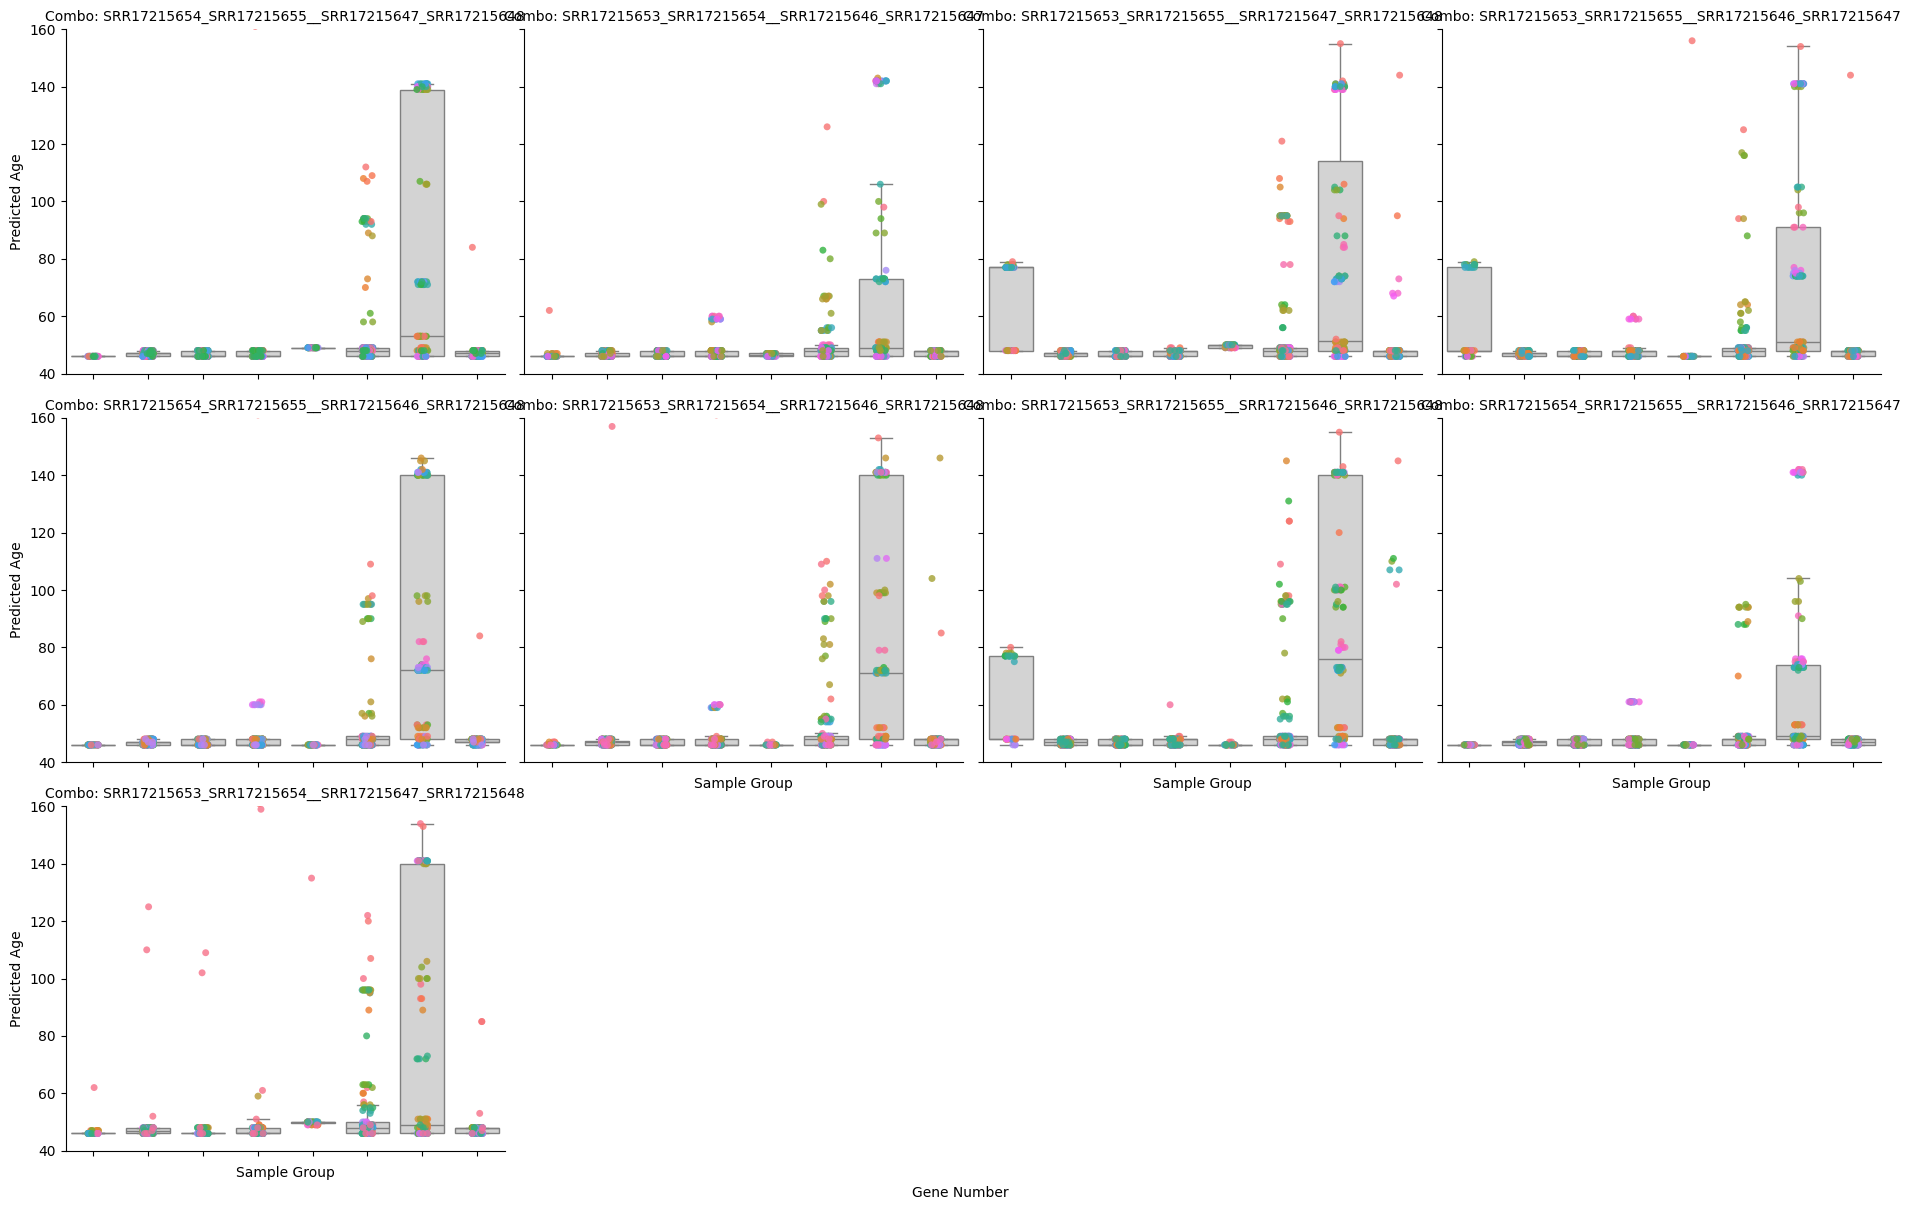

In [35]:
# Plotting preferences
ordered_x = [
    '46_WT_full', '46_Het_full',
    '46_WT_fasted', '46_Het_fasted',
    '105_WT_full', '105_Het_full',
    '105_WT_fasted', '105_Het_fasted'
]

# Load prediction files
all_predictions_list = []
prediction_files = glob("./predictions_exhaustive/pred_top_*.tsv")

for file_path in prediction_files:
    filename = os.path.basename(file_path).replace(".tsv", "")
    match = re.match(r"pred_top_(\d+)_(.+)", filename)
    if match:
        gene_number, combo_id = match.groups()
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = int(gene_number)
        df["combo_id"] = combo_id
        df["gene_number_str"] = f"{gene_number} genes"
        all_predictions_list.append(df)

# Combine into one dataframe
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Create the base catplot
g = sns.catplot(
    data=all_predictions_df,
    x="age_genotype_treatment",
    y="prediction",
    col="combo_id",
    col_wrap=4,
    kind="box",
    color="lightgray",
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Use a single color palette for gene numbers
unique_gene_numbers = all_predictions_df["gene_number_str"].unique()
palette = sns.color_palette("husl", len(unique_gene_numbers))
gene_color_map = dict(zip(sorted(unique_gene_numbers, key=lambda x: int(x.split()[0])), palette))

# Overlay stripplots with gene number coloring
for ax, combo_id in zip(g.axes.flat, all_predictions_df["combo_id"].unique()):
    subset = all_predictions_df[all_predictions_df["combo_id"] == combo_id]
    sns.stripplot(
        x='age_genotype_treatment',
        y='prediction',
        data=subset,
        hue='gene_number_str',
        palette=gene_color_map,
        dodge=False,
        jitter=True,
        alpha=0.8,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False  # Don't draw legend here
    )
    ax.set_title(f"Combo {combo_id[:12]}…")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Combo: {col_name}")
g.tight_layout()

# Draw separate legend
fig = plt.gcf()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Gene Number", loc='lower center', ncol=6, frameon=False, bbox_to_anchor=(0.5, -0.02))

# Save
plt.savefig("./plots/predictions_by_combo_colored_by_gene_number_separate_legend.svg", dpi=300, bbox_inches="tight")
plt.show()


In [36]:
all_predictions_df

,prediction,feeding_condition,genotype,age,age_genotype_treatment,gene_number,combo_id,gene_number_str
SRR17215646,49.0,full,WT,105,105_WT_full,40,SRR17215654_SRR17215655__SRR17215647_SRR17215648,40 genes
SRR17215657,46.0,full,Het,46,46_Het_full,40,SRR17215654_SRR17215655__SRR17215647_SRR17215648,40 genes
SRR17215658,48.0,full,Het,46,46_Het_full,40,SRR17215654_SRR17215655__SRR17215647_SRR17215648,40 genes
SRR17215659,46.0,full,Het,46,46_Het_full,40,SRR17215654_SRR17215655__SRR17215647_SRR17215648,40 genes
SRR17215660,53.0,fasted,WT,105,105_WT_fasted,40,SRR17215654_SRR17215655__SRR17215647_SRR17215648,40 genes
...,...,...,...,...,...,...,...,...
SRR17215650,46.0,full,Het,105,105_Het_full,160,SRR17215654_SRR17215655__SRR17215646_SRR17215648,160 genes
SRR17215651,49.0,full,Het,105,105_Het_full,160,SRR17215654_SRR17215655__SRR17215646_SRR17215648,160 genes
SRR17215652,48.0,full,Het,105,105_Het_full,160,SRR17215654_SRR17215655__SRR17215646_SRR17215648,160 genes
SRR17215653,46.0,full,WT,46,46_WT_full,160,SRR17215654_SRR17215655__SRR17215646_SRR17215648,160 genes


# Evaluate rotation results

In [ ]:
# Define the group pairs to compare: (WT, Het)
group_pairs = [
    ('46_WT_full', '46_Het_full'),
    ('46_WT_fasted', '46_Het_fasted'),
    ('105_WT_full', '105_Het_full'),
    ('105_WT_fasted', '105_Het_fasted')
]

# Initialize results
separation_results = []

# Group by each combination of gene_number and combo_id
grouped = all_predictions_df.groupby(['gene_number', 'combo_id'])

for (gene_number, combo_id), group_df in grouped:
    result = {
        "gene_number": gene_number,
        "combo_id": combo_id
    }

    for wt_group, het_group in group_pairs:
        try:
            wt_preds = group_df[group_df["age_genotype_treatment"] == wt_group]["prediction"].astype(float)
            het_preds = group_df[group_df["age_genotype_treatment"] == het_group]["prediction"].astype(float)

            # Compute separation score (mean difference: Het - WT)
            if not wt_preds.empty and not het_preds.empty:
                separation_score = het_preds.mean() - wt_preds.mean()
            else:
                separation_score = float('nan')
        except Exception as e:
            print(f"Error processing {gene_number}, {combo_id}, {wt_group} vs {het_group}: {e}")
            separation_score = float('nan')

        score_label = f"sep_{het_group}_minus_{wt_group}"
        result[score_label] = separation_score

    separation_results.append(result)

# Create the final separation DataFrame
het_vs_wt_separation_df = pd.DataFrame(separation_results)

# View result
print(het_vs_wt_separation_df.head())


   gene_number                                          combo_id  \
0            5  SRR17215653_SRR17215654__SRR17215646_SRR17215647   
1            5  SRR17215653_SRR17215654__SRR17215646_SRR17215648   
2            5  SRR17215653_SRR17215654__SRR17215647_SRR17215648   
3            5  SRR17215653_SRR17215655__SRR17215646_SRR17215647   
4            5  SRR17215653_SRR17215655__SRR17215646_SRR17215648   

   sep_46_Het_full_minus_46_WT_full  sep_46_Het_fasted_minus_46_WT_fasted  \
0                             -0.25                              0.833333   
1                             27.00                              1.083333   
2                             21.25                             -6.166667   
3                             -1.25                              1.083333   
4                             -1.25                              1.333333   

   sep_105_Het_full_minus_105_WT_full  sep_105_Het_fasted_minus_105_WT_fasted  
0                                1.00           

In [ ]:
# Sort the DataFrame by the separation score of interest
sorted_sep_df = het_vs_wt_separation_df.sort_values(
    by='sep_105_Het_full_minus_105_WT_full',
    ascending=True
)

# Display the top rows
#print(sorted_sep_df.head())


In [ ]:
sorted_sep_df

,gene_number,combo_id,sep_46_Het_full_minus_46_WT_full,sep_46_Het_fasted_minus_46_WT_fasted,sep_105_Het_full_minus_105_WT_full,sep_105_Het_fasted_minus_105_WT_fasted
12,10,SRR17215653_SRR17215655__SRR17215646_SRR17215647,-1.00,1.083333,-77.50,-5.333333
2,5,SRR17215653_SRR17215654__SRR17215647_SRR17215648,21.25,-6.166667,-49.75,-38.000000
200,115,SRR17215653_SRR17215654__SRR17215647_SRR17215648,1.00,0.500000,-2.75,-31.000000
248,140,SRR17215653_SRR17215655__SRR17215647_SRR17215648,-30.00,0.333333,-2.25,-39.666667
254,145,SRR17215653_SRR17215654__SRR17215647_SRR17215648,1.00,0.500000,-2.25,-30.666667
...,...,...,...,...,...,...
9,10,SRR17215653_SRR17215654__SRR17215646_SRR17215647,-15.25,1.083333,33.50,-2.000000
23,15,SRR17215653_SRR17215655__SRR17215647_SRR17215648,-31.00,1.083333,35.25,-36.333333
14,10,SRR17215653_SRR17215655__SRR17215647_SRR17215648,-32.00,1.083333,39.75,-37.000000
13,10,SRR17215653_SRR17215655__SRR17215646_SRR17215648,-33.00,1.083333,44.00,-37.000000


### Plot predictions for particular samples used in training

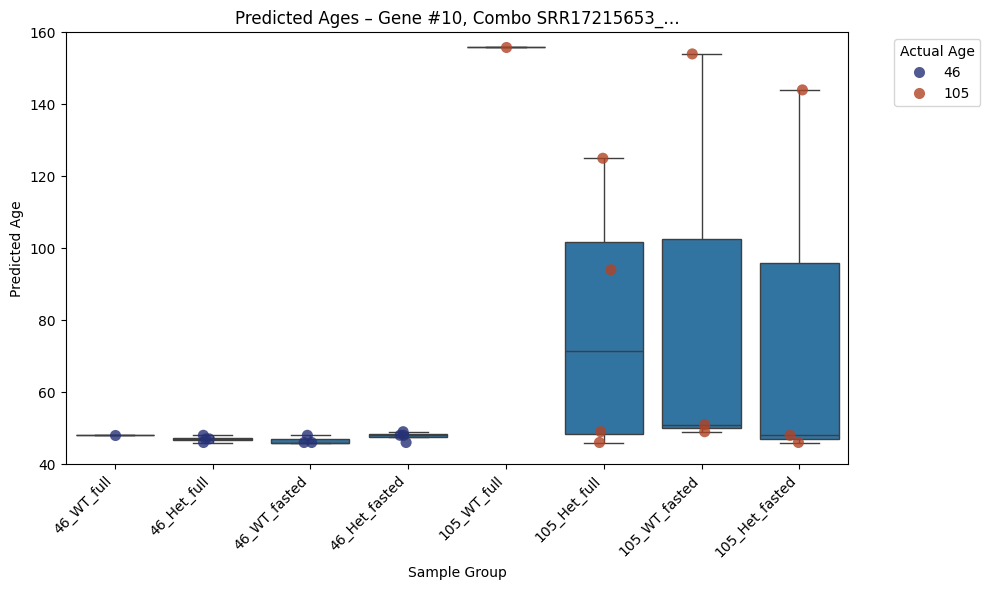

In [ ]:
# --- Plotting preferences ---
ordered_x = [
    '46_WT_full', '46_Het_full',
    '46_WT_fasted', '46_Het_fasted',
    '105_WT_full', '105_Het_full',
    '105_WT_fasted', '105_Het_fasted'
]

custom_palette = ['#273276', '#B14325']  # Optional: custom color palette for age

# --- Inputs ---
selected_gene_number = 10  # change to desired gene number
selected_combo_id = "SRR17215653_SRR17215655__SRR17215646_SRR17215647"  # change to desired combo ID

# --- Filter data ---
subset_df = all_predictions_df[
    (all_predictions_df["gene_number"] == selected_gene_number) &
    (all_predictions_df["combo_id"] == selected_combo_id)
].copy()

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="age_genotype_treatment",
    y="prediction",
    data=subset_df,
    showfliers=False,
    order=ordered_x
)

sns.stripplot(
    x="age_genotype_treatment",
    y="prediction",
    data=subset_df,
    hue="age",
    palette=custom_palette,
    dodge=False,
    alpha=0.8,
    jitter=True,
    size=8,
    order=ordered_x
)

plt.title(f"Predicted Ages – Gene #{selected_gene_number}, Combo {selected_combo_id[:12]}…")
plt.xlabel("Sample Group")
plt.ylabel("Predicted Age")
plt.xticks(rotation=45, ha='right')
plt.ylim(40, 160)
plt.legend(title="Actual Age", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
